<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/L4_Descriptive_Stats%26Prob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Viz Helpers

In [ ]:
# === DATA + PICTURE HELPERS — run this cell, then ignore it ========
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]

def load_airtel(seed=7, n=1000):
    "Airtel case-study data — simulated for teaching, not real company figures."
    rng = np.random.default_rng(seed)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.21, 0.24])
    is_new = rng.random(n) < np.where(contract == "Month-to-month", 0.65, 0.15)
    tenure = np.where(is_new, rng.integers(1, 13, n),
                      np.clip(rng.normal(54, 9, n), 24, 72).round())
    charges = np.where(contract == "Month-to-month", 20 + rng.gamma(2.0, 22, n),
               np.where(contract == "One year", rng.normal(64, 9, n), rng.normal(78, 11, n)))
    calls = rng.poisson(1.3, n)
    locked = np.where(contract == "Two year", 0.25, 1.0)
    p = (0.02 + np.where(contract == "Month-to-month", 0.28, 0)
              + np.where(contract == "One year", 0.06, 0)
              + 0.07 * np.minimum(calls, 4) * locked + 0.06 * (tenure < 12))
    return pd.DataFrame({
        "tenure_months":   tenure.astype(int),
        "monthly_charges": np.clip(charges, 18, 220).round(2),
        "contract":        contract,
        "support_calls":   calls,
        "churned":         (rng.random(n) < np.clip(p, 0, 0.95)).astype(int)})

def _axes(title, xlabel, ylabel, size=(6, 4)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def show_hist(values, title, xlabel, marks=None, bins=30):
    "Histogram, with optional labelled vertical lines (e.g. the mean and median)."
    ax = _axes(title, xlabel, "number of customers")
    ax.hist(values, bins=bins, color=COLORS[0], alpha=0.85)
    for i, (name, v) in enumerate((marks or {}).items()):
        ax.axvline(v, color=COLORS[i % 2 + 1], lw=2, ls="--")
        ax.annotate(f"{name} = {v:.1f}", (v, ax.get_ylim()[1] * (0.92 - 0.1 * i)),
                    xytext=(9, 0), textcoords="offset points",
                    color=COLORS[i % 2 + 1], fontsize=9)
    plt.show()

def compare_hist(groups, title, xlabel, bins=30):
    "Overlay histograms of two or three groups."
    ax = _axes(title, xlabel, "number of customers")
    for i, (name, values) in enumerate(groups.items()):
        ax.hist(values, bins=bins, color=COLORS[i % 3], alpha=0.55, label=name)
    ax.legend(frameon=False, fontsize=9); plt.show()

def show_bars(labels, values, title, ylabel, baseline=None, baseline_label=""):
    "Bar chart, with an optional dashed reference line across it."
    ax = _axes(title, "", ylabel, (6, 4))
    ax.bar([str(l) for l in labels], values, color=COLORS[0], width=0.6)
    for x, v in zip(range(len(values)), values):
        ax.annotate(f"{v:.3f}", (x, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9)
    if baseline is not None:
        ax.axhline(baseline, color=COLORS[1], lw=2, ls="--")
        ax.annotate(baseline_label, (len(values) - 1, baseline), xytext=(0, 6),
                    textcoords="offset points", ha="right", color=COLORS[1], fontsize=9)
    ax.margins(y=0.18); plt.show()

def show_box(groups, title, ylabel):
    "Box plot: the middle line is the median, the box holds the middle 50%."
    ax = _axes(title, "", ylabel, (6, 4))
    ax.boxplot(list(groups.values()), tick_labels=list(groups.keys()),
               medianprops=dict(color=COLORS[1], lw=2))
    plt.show()

## Dataset

In [ ]:
df = load_airtel()
print("Airtel customer file loaded:", df.shape)

Airtel customer file loaded: (1000, 5)


In [ ]:
df.head()

,tenure_months,monthly_charges,contract,support_calls,churned
0,35,51.55,One year,1,0
1,48,72.91,Two year,3,0
2,36,84.55,Two year,1,0
3,6,53.97,Month-to-month,2,0
4,5,48.55,Month-to-month,1,1


In [ ]:
print("churned  :", df["churned"].sum())
print("churned  :", df["churned"].mean())

churned  : 280
churned  : 0.28


In [ ]:
# randomly call 200 customers,
# only 56 customers calls are worth.

In [ ]:
print("monthly charges — mean  :", round(df["monthly_charges"].mean(), 2))
print("monthly charges — median  :", round(df["monthly_charges"].median(), 2))

monthly charges — mean  : 66.47
monthly charges — median  : 65.22


In [ ]:
# mean influenced by -> (min, max) value

In [ ]:
heights = np.array([170, 212, 165, 172, 180, 182, 168, 200])
heights

array([170, 165, 172, 180, 182, 168, 212, 200])

In [ ]:
heights.mean()

np.float64(181.125)

In [ ]:
np.median(heights)

np.float64(176.0)

In [ ]:
print("monthly charges — mean  :", round(df["tenure_months"].mean(), 2))
print("monthly charges — median  :", round(df["tenure_months"].median(), 2))

monthly charges — mean  : 34.53
monthly charges — median  : 45.0


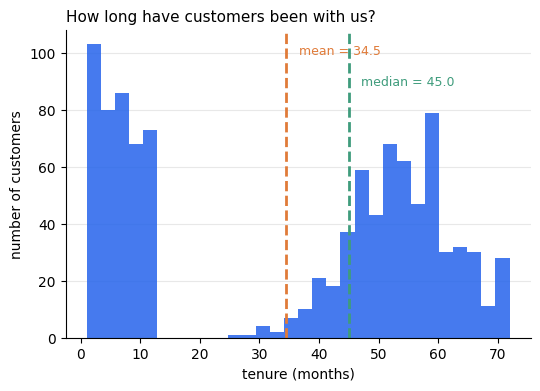

In [ ]:
# plt.hist

show_hist(df["tenure_months"], "How long have customers been with us?", "tenure (months)",
          marks={"mean": df["tenure_months"].mean(), "median": df["tenure_months"].median()})

In [ ]:
df.head()

,tenure_months,monthly_charges,contract,support_calls,churned
0,35,51.55,One year,1,0
1,48,72.91,Two year,3,0
2,36,84.55,Two year,1,0
3,6,53.97,Month-to-month,2,0
4,5,48.55,Month-to-month,1,1


In [ ]:
df['contract'].value_counts()

,count
contract,
Month-to-month,552
Two year,233
One year,215


In [ ]:
print("most common contract (the mode):", df["contract"].mode()[0])

'Month-to-month'

In [ ]:
df.head()

,tenure_months,monthly_charges,contract,support_calls,churned
0,35,51.55,One year,1,0
1,48,72.91,Two year,3,0
2,36,84.55,Two year,1,0
3,6,53.97,Month-to-month,2,0
4,5,48.55,Month-to-month,1,1


1. mean, median support_calls,
2. hist, support_calls
3. count the frequency of support_calls.

In [ ]:
df['support_calls'].mean(), df['support_calls'].median()

(np.float64(1.324), 1.0)

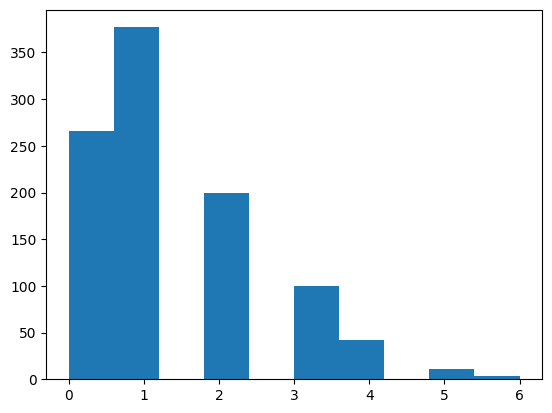

In [ ]:
plt.hist(df['support_calls'], bins = 10);

In [ ]:
df['support_calls'].value_counts()

,count
support_calls,
1,377
0,266
2,200
3,100
4,42
5,11
6,4


## Spreadness

In [ ]:
# Variance = avg distance sq around mean value
# Std  = sqrt(var)

In [ ]:
monthly = df[df['contract'] == 'Month-to-month']['monthly_charges']
yearly = df[df['contract'] == 'One year']['monthly_charges']

print(monthly.mean(), yearly.mean())
print(monthly.std(), yearly.std())

63.21327898550725 63.571953488372095
30.052347310716243 9.096287673390666


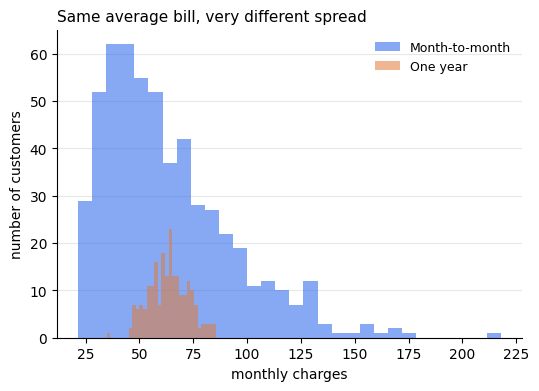

In [ ]:
compare_hist({"Month-to-month": monthly, "One year": yearly},
             "Same average bill, very different spread", "monthly charges")

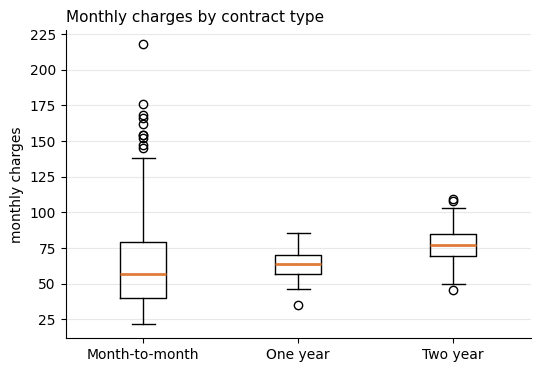

In [ ]:
# plt.boxplot
# sns.boxplot

show_box({c: df[df["contract"] == c]["monthly_charges"] for c in sorted(df["contract"].unique())},
         "Monthly charges by contract type", "monthly charges")

In [ ]:
# Z-scores.  (standard normal distribution)
charges = df['monthly_charges']
charges.head()

,monthly_charges
0,51.55
1,72.91
2,84.55
3,53.97
4,48.55


In [ ]:
z = (charges - charges.mean())/ charges.std()

((z <= -2) | (z >=2) ).sum()

np.int64(40)

In [ ]:
# P(event) = how many times event happened / total chances

In [ ]:
p_churn = df["churned"].sum() / len(df)
print("P(churn) =", round(p_churn, 3))

P(churn) = 0.28


In [ ]:
print("P(stayed) =", round(1 - p_churn, 3))

P(stayed) = 0.72


In [ ]:
# A = customers are type of month-to-month
# B = customer who do more than >=3 calls.

# P( A or B ) = P(A) + P(B) - P(A and B)

In [ ]:
m2m = (df['contract'] == 'Month-to-month')
many_calls = (df['support_calls'] >=3)


p_m2m = m2m.mean()
p_many_calls = many_calls.mean()
p_and = (m2m & many_calls).mean()

print("P(month-by-month):", p_m2m)
print("P(>=3calls):", p_many_calls)
print("P(both):", p_and)

print("P(month-by-month or >=3 calls):",  round(p_m2m + p_many_calls - p_and, 3))

P(month-by-month): 0.552
P(>=3calls): 0.157
P(both): 0.077
P(month-by-month or >=3 calls): 0.632


In [ ]:
157/1000

0.157

In [ ]:
552/1000

0.552

In [ ]:
df.head()

,tenure_months,monthly_charges,contract,support_calls,churned
0,35,51.55,One year,1,0
1,48,72.91,Two year,3,0
2,36,84.55,Two year,1,0
3,6,53.97,Month-to-month,2,0
4,5,48.55,Month-to-month,1,1


In [ ]:
(m2m & many_calls).mean()

np.float64(0.077)

## Conditional Probability

In [ ]:
# Given that a customer is on month-to-month contract, what is the probability they churn ?

In [ ]:
# P(churn) = 0.28

In [ ]:
# A = churn
# B = customer is month-to-month

# P( A | B ) = P(A and B) / P(B)

In [ ]:
A = 0.28
B = 0.552
AndB = ((df['contract']=='Month-to-month') &(df['churned']==1)).mean() # 0.223

In [ ]:
df.head()

,tenure_months,monthly_charges,contract,support_calls,churned
0,35,51.55,One year,1,0
1,48,72.91,Two year,3,0
2,36,84.55,Two year,1,0
3,6,53.97,Month-to-month,2,0
4,5,48.55,Month-to-month,1,1


In [ ]:
print("P(A and B) / P(B) =", round(AndB / B, 3))

P(A and B) / P(B) = 0.404


In [ ]:
# P(churn | two year subscription) =

In [ ]:
df.groupby('contract')['churned'].mean()

,churned
contract,
Month-to-month,0.403986
One year,0.204651
Two year,0.055794


In [ ]:
# 1000 customers.
# retention 200 customers.



In [ ]:
m2m.sum()

np.int64(552)

In [ ]:
200*0.4 # call 80 people. give them discounts, retain them.

80.0

In [ ]:
churn_by_contract = df.groupby("contract")["churned"].mean()
churn_by_contract.round(3)

,churned
contract,
Month-to-month,0.404
One year,0.205
Two year,0.056


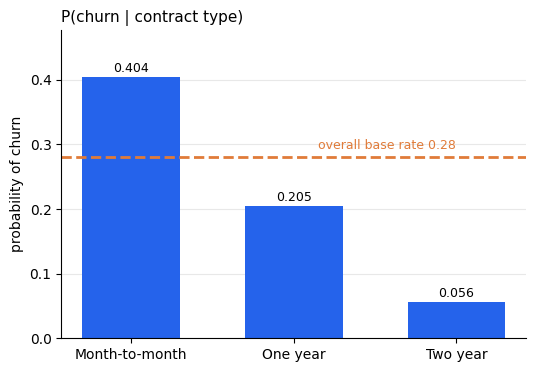

In [ ]:
show_bars(churn_by_contract.index, churn_by_contract.values,
          "P(churn | contract type)", "probability of churn",
          baseline=df["churned"].mean(), baseline_label="overall base rate 0.28")

In [ ]:
# P(churn| call>=2)
noisy = df[df["support_calls"] >= 2]
print("P(churn | 2+  support calls) :", round(noisy["churned"].mean(), 3))

P(churn | 2+  support calls) : 0.359


In [ ]:
at_risk = (df["contract"] == "Month-to-month") & (df["support_calls"] >= 2)

flagged = df[at_risk]

flagged['churned'].mean()

np.float64(0.4720812182741117)

In [ ]:
flagged['churned'].sum()

np.int64(93)

In [ ]:
# flagged

In [ ]:
# P ( churn | month-to-month & calls>=2 ) = 93/197

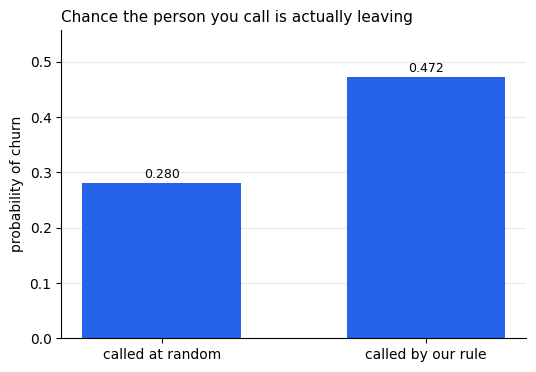

In [ ]:
show_bars(["called at random", "called by our rule"],
          [df["churned"].mean(), flagged["churned"].mean()],
          "Chance the person you call is actually leaving", "probability of churn")

In [ ]:
flagged

,tenure_months,monthly_charges,contract,support_calls,churned
3,6,53.97,Month-to-month,2,0
10,71,69.45,Month-to-month,3,1
11,7,73.02,Month-to-month,2,0
12,6,109.65,Month-to-month,3,1
23,10,70.54,Month-to-month,2,0
...,...,...,...,...,...
973,12,132.12,Month-to-month,3,0
974,46,52.96,Month-to-month,2,0
983,6,44.38,Month-to-month,4,0
985,3,74.79,Month-to-month,2,0


In [ ]:
m2m

,contract
0,False
1,False
2,False
3,True
4,True
...,...
995,False
996,False
997,True
998,False


In [ ]:
m2m.sum() # counts all TRue

np.int64(552)

In [ ]:
m2m.count()

np.int64(1000)

In [ ]:
df.head()

,tenure_months,monthly_charges,contract,support_calls,churned
0,35,51.55,One year,1,0
1,48,72.91,Two year,3,0
2,36,84.55,Two year,1,0
3,6,53.97,Month-to-month,2,0
4,5,48.55,Month-to-month,1,1


In [ ]:
mu = df['monthly_charges'].mean()
mu

np.float64(66.47425)

In [ ]:
sig = df['monthly_charges'].std()
sig

23.98474243153356

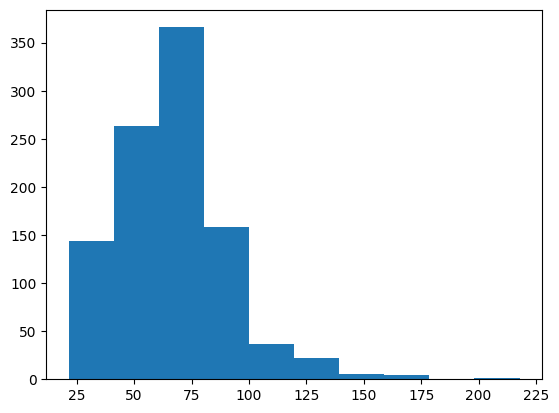

In [ ]:
plt.hist(df['monthly_charges']);

In [ ]:
z = (df['monthly_charges'] - mu)/sig

In [ ]:
z # standarscaler

,monthly_charges
0,-0.622239
1,0.268327
2,0.753635
3,-0.521342
4,-0.747319
...,...
995,0.515567
996,0.119899
997,-1.008318
998,0.244979


(array([144., 263., 366., 158.,  37.,  22.,   5.,   4.,   0.,   1.]),
 array([-1.87595302, -1.05726589, -0.23857876,  0.58010838,  1.39879551,
         2.21748264,  3.03616977,  3.85485691,  4.67354404,  5.49223117,
         6.3109183 ]),
 <BarContainer object of 10 artists>)

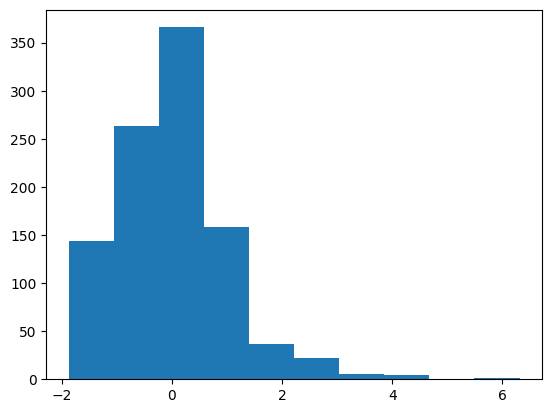

In [ ]:
plt.hist(z)

In [ ]:
z.mean()

np.float64(9.237055564881302e-17)

In [ ]:
z.std()

1.000000000000001